# Multipopulation mass distribution

Plot the component-mass distribution from `multipopulation_broken_powerlaw_multi_peak_gaussian` over $1\leq m/M_\odot\leq150$. The model is instantiated with its default shape parameters, except that `mmax=150`.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from gwcosmo.prior.priors import multipopulation_broken_powerlaw_multi_peak_gaussian

plt.style.use("seaborn-v0_8-whitegrid")

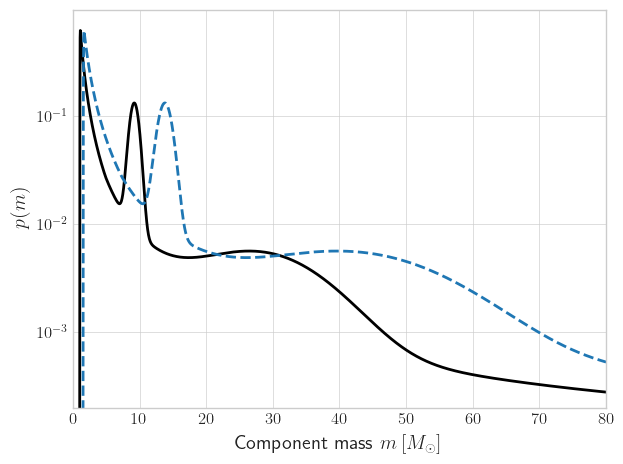

In [36]:
mass_model = multipopulation_broken_powerlaw_multi_peak_gaussian(
    alpha_1=2.1, alpha_2=1.8, mmin=1.0, mmax=112.5, lambda_g=0.3,
    lambda_g_low=0.7, mu_g_low=9.2, sigma_g_low=0.7, mu_g_high=28, sigma_g_high=8.65, 
    delta_m_low_pass=1, delta_m_high_pass=0.1, A=0, notch_left=2.3, notch_right=7.0, 
    notch_smooth_left=1, notch_smooth_right=0.5
)

mass = np.linspace(1.0, 100.0, 3000)
pdf = mass_model.mdis["mass_1"].prob(mass)
pdf /= np.trapz(pdf, mass)

fig, ax = plt.subplots()
ax.semilogy(mass, pdf+0.0001, color="k", linewidth=2)
ax.semilogy(mass*1.5, pdf+0.0001, color="tab:blue", linewidth=2, linestyle="--")
# ax.fill_between(mass, pdf, color="tab:blue", alpha=0.18)
ax.set(
    xlim=(0, 80),
    ylim=(2e-4, None),
    xlabel=r"Component mass $m\,[M_\odot]$",
    ylabel=r"$p(m)$",
    # title="Multipopulation broken power law + two Gaussian peaks",
)
# ax.set_yscale("log")
ax.grid(alpha=0.9)
fig.tight_layout()
plt.savefig("../plots/multipopulation_mass_distribution.png", dpi=300, bbox_inches="tight")

In [10]:
pdf

array([0.        , 0.17219202, 0.33304209, ..., 0.        ,
       0.        , 0.        ])